# Файлы в Python

NumPy предоставляет удобные инструменты обмена между массивами и файлами. 

## 1.  Двоичные файлы NumPy (.npy, .npz) 

Существуют 2 типа двоичных файлов в NumPy:
+ .npy служит для  хранения несжатых массивов;
+ .npz служит для  хранения сжатых массивов (zip).
    
Для записи файлов в формате .npy служит функция 
```
numpy.save(file,name)
```

Здесь 
+ file – строка, содержащая имя файла;
+ name – имя массива, который записывается в файл.
  
Массив загрузить из файла с помощью функции 
```
numpy.load(file)
```

**Пример 1.** Записать в файл с расширением .npy и считать из него матрицу $$A_{i,j}=\begin{cases} \begin{align}&2.7\cdot n,&i=j\\&1 ,&i \neq j \end{align} \end{cases}$$.

Программа записи в файл

In [1]:
import numpy
N=int(input('N='));
A=numpy.ones([N,N]);
for i in range(0,N):
    for j in range(0,N):
        if (i==j):
            A[i][j]=2.7*N
        else:
            A[i][j]=1
numpy.save('matr.npy',A)

N= 5


Вторая программа чтения данных из файла

In [2]:
import numpy
import sys
def printf(format, *args):
    sys.stdout.write(format % args)
bb=numpy.load('matr.npy')
(n1,m1)=bb.shape
printf("n1=%d,\tm1=%d\n",n1,m1)
printf("Считанная из файла матрица\n")
for i in range(0,n1):
    for j in range (0,m1):
        printf("%6.3f\t",bb[i][j])
    printf("\n")

n1=5,	m1=5
Считанная из файла матрица
13.500	 1.000	 1.000	 1.000	 1.000	
 1.000	13.500	 1.000	 1.000	 1.000	
 1.000	 1.000	13.500	 1.000	 1.000	
 1.000	 1.000	 1.000	13.500	 1.000	
 1.000	 1.000	 1.000	 1.000	13.500	


Если же необходимо записать несколько массивов в файл, то можно воспользоваться функцией 
```
numpy.savez(file, name1, name2, name3,...)1,
```
Здесь 
+ **file** – строка, содержащая имя файла;
+ **namei** – имена массивов, которые записываются в файл.
  
которая сохранит их в несжатом виде в файле NumPy с форматом .npz. 
Чтение из файлов осуществляется функцией numpy.load.

**Пример 2**. Записать в файл с расширением .npz и считать из него матрицу $A_{i,j}=\begin{cases} \begin{align}&2\cdot n,&i=j\\&1 ,&i \neq j \end{align} \end{cases}$ и  массив $b_i=\frac{n \cdot (n+1)}{2} +(i+1) \cdot (2 \cdot n -1)$.

Программа создания файла.


In [3]:
import numpy
N=int(input('N='));
A=numpy.ones([N,N]);
b=numpy.ones(N);
for i in range(0,N):
    for j in range(0,N):
        if (i==j):
            A[i,j]=2*N
        else:
            A[i,j]=1
    b[i]=N*(N+1)/2+(i+1)*(2*N-1)
numpy.savez('matr.npz',A,b)

N= 7


Программа чтения из файла

In [4]:
import numpy
c=numpy.load('matr.npz')
print(c.files)

['arr_0', 'arr_1']


Создаётся архив matr.npz.

![image.png](1.png)

Чтобы достать матрицу **A** и массив **b** из архива допишем в код чтения из массива ещё пару строчек.

In [5]:
import numpy
c=numpy.load('matr.npz')
print(c.files)
a=c['arr_0'];
print('Матрица А='); print(a);
b=c['arr_1'];
print('Массив B='); print(b);

['arr_0', 'arr_1']
Матрица А=
[[14.  1.  1.  1.  1.  1.  1.]
 [ 1. 14.  1.  1.  1.  1.  1.]
 [ 1.  1. 14.  1.  1.  1.  1.]
 [ 1.  1.  1. 14.  1.  1.  1.]
 [ 1.  1.  1.  1. 14.  1.  1.]
 [ 1.  1.  1.  1.  1. 14.  1.]
 [ 1.  1.  1.  1.  1.  1. 14.]]
Массив B=
[ 41.  54.  67.  80.  93. 106. 119.]


Возникает вопрос, можно или изменить имена файлов **('arr_0', 'arr_1',…,'arr_n')** в создаваемом архиве? Можно, для этого необходимо в функции numpy.savez() указывать их как ключи словарей Python. Модифицируем программы чтения и записи файлов.

Программа записи данных в файл.


In [6]:
import numpy
N=int(input('N='));
A=numpy.ones([N,N]);
b=numpy.ones(N);
for i in range(0,N):
    for j in range(0,N):
        if (i==j):
            A[i,j]=2*N
        else:
            A[i,j]=1
    b[i]=N*(N+1)/2+(i+1)*(2*N-1)
numpy.savez('matr2.npz',A=A, b=b)
print(A)
print(b)

N= 6


[[12.  1.  1.  1.  1.  1.]
 [ 1. 12.  1.  1.  1.  1.]
 [ 1.  1. 12.  1.  1.  1.]
 [ 1.  1.  1. 12.  1.  1.]
 [ 1.  1.  1.  1. 12.  1.]
 [ 1.  1.  1.  1.  1. 12.]]
[32. 43. 54. 65. 76. 87.]


In [7]:
import numpy
c=numpy.load('matr2.npz')
print(c.files)
a=c['A'];
print('Матрица А='); print(a);
b=c['b'];
print('Массив B='); print(b);

['A', 'b']
Матрица А=
[[12.  1.  1.  1.  1.  1.]
 [ 1. 12.  1.  1.  1.  1.]
 [ 1.  1. 12.  1.  1.  1.]
 [ 1.  1.  1. 12.  1.  1.]
 [ 1.  1.  1.  1. 12.  1.]
 [ 1.  1.  1.  1.  1. 12.]]
Массив B=
[32. 43. 54. 65. 76. 87.]


Для записи массивов в двоичный файл также можно использовать метод **tofile**
```
numpy.tofile(file)
```
Здесь **file** – строка с именем файла

Что бы загрузить массив из такого файла необходимо воспользоваться функцией модуля Numpy .
```
numpy.fromfile()
```
**Пример 3.** Записать в двоичные файлы и считать из них матрицу $$A_{i,j}=\begin{cases} \begin{align}&\frac{3}{3}\cdot n,&i=j\\&1 + \frac{1}{i+j},&i \neq j \end{align} \end{cases}$$ и  массив $$b_i=\frac{3}{7} \cdot n \cdot (n+1) +(i+1) \cdot (2 \cdot n -1)$$. 

Программа записи данных в двоичный файл.


In [8]:
import numpy
N=int(input('N='));
A=numpy.ones([N,N]);
b=numpy.ones(N);
for i in range(0,N):
    for j in range(0,N):
        if (i==j):
            A[i,j]=7/3*N
        else:
            A[i,j]=1+1/(i+j)
    b[i]=3/7*N*(N+1)+(i+1)*(2*N-1)
print(A)
print(b)
A.tofile('A.dat')
b.tofile('b.dat')

N= 4


[[9.33333333 2.         1.5        1.33333333]
 [2.         9.33333333 1.33333333 1.25      ]
 [1.5        1.33333333 9.33333333 1.2       ]
 [1.33333333 1.25       1.2        9.33333333]]
[15.57142857 22.57142857 29.57142857 36.57142857]


Программа чтения данных из двоичного файла.

In [9]:
import numpy
A=numpy.fromfile('A.dat')
print('A=','\n',A)
b=numpy.fromfile('b.dat')
print('b=','\n',b)

A= 
 [9.33333333 2.         1.5        1.33333333 2.         9.33333333
 1.33333333 1.25       1.5        1.33333333 9.33333333 1.2
 1.33333333 1.25       1.2        9.33333333]
b= 
 [15.57142857 22.57142857 29.57142857 36.57142857]


## 2. Текстовые файлы

Numpy предоставляет довольно гибкий механизм работы и с текстовыми файлами. Рассмотрим функции **numpy.savetxt()** и **numpy.loadtxt()**.

**Пример 3.** Записать в текстовые файлы и считать из них матрицу $A_{i,j}=\begin{cases} \begin{align}&2\cdot n,&i=j\\&1 ,&i \neq j \end{align} \end{cases}$ и  массив $b_i=\frac{n \cdot (n+1)}{2} +(i+1) \cdot (2 \cdot n -1)$.

Программа создания файла.


In [12]:
import numpy
N=int(input('N='));
A=numpy.ones([N,N]);
b=numpy.ones(N);
for i in range(0,N):
    for j in range(0,N):
        if (i==j):
            A[i,j]=2*N
        else:
            A[i,j]=1
    b[i]=N*(N+1)/2+(i+1)*(2*N-1)
numpy.savetxt('matrA.txt',A)
numpy.savetxt('matrb.txt',b)
print(A)
print(b)

N= 4


[[8. 1. 1. 1.]
 [1. 8. 1. 1.]
 [1. 1. 8. 1.]
 [1. 1. 1. 8.]]
[17. 24. 31. 38.]


Содержимое файлов (при N=4)

![image.png](2.png)

![image.png](3.png)

Программа чтения данных из файла.

In [13]:
import numpy
A=numpy.loadtxt('matrA.txt')
print('A=','\n',A)
b=numpy.loadtxt('matrb.txt')
print('b=','\n',b)

A= 
 [[8. 1. 1. 1.]
 [1. 8. 1. 1.]
 [1. 1. 8. 1.]
 [1. 1. 1. 8.]]
b= 
 [17. 24. 31. 38.]


#  Примеры практических задач в Python
В качестве практических задач рассмотрим задачи подбора кривых методом наименьших квадратов (МНК). МНК подробно описан во многих книгах. Например тут https://dmkpress.com/catalog/computer/mathematics/978-5-93700-271-6/, https://www.altlinux.org/Images.www.altlinux.org/3/3a/Scilab.pdf

**Задача 5.** В «Основах химии» Д.И. Менделеева приводятся данные о растворимости $Na NO_3$  (P) в зависимости от температуры воды. В 100 частях воды растворяется следующее число условных частей  при соответствующих температурах.

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> |
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| $T, ^oC$ | 0        | 4        | 10       | 15       |21      | 29 | 36       | 51       |58      |
| P        | 66.7     | 71       | 76.3        | 80.6        |85.7        | 92.9 | 99.4        | 113.6       |125.1        |


Температура 32°С не входит в наблюдаемые значения. Необходимо определить, какова будет растворимость $NaNO_3$   при соответствующих температурах. 

Ниже приведен код программы решения задачи


(0, 68)
[67.50779419813904, 126.71134099616856]
32 95.36828680897646


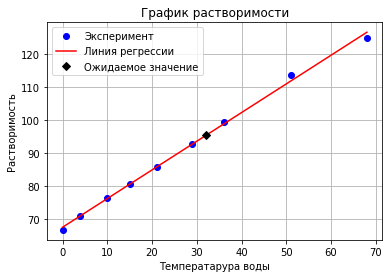

In [1]:
from matplotlib.pyplot import *
from numpy import *
T=array([0,4,10,15,21,29,36,51,68]);
P=array([66.7,71,76.3,80.6,85.7,92.9,99.4,113.6,125.1]);
n=T.size;
Mt=sum(T)/n;Mp=sum(P)/n;
b=(n*sum(T*P)-sum(P)*sum(T))/(n*sum(T*T)-sum(T)**2);
a=Mp-b*Mt;
Tl=(T[0],T[n-1]);
Pl=[]
for i in range(2):
    Pl.append(a+b*Tl[i]);
print(Tl);
print(Pl);
T1=32;
P1=a+b*T1;
print(T1,P1);
plot(T,P,'bo',label="Эксперимент");
plot(Tl,Pl,'r',label="Линия регрессии");
plot(T1,P1,'kD',label="Ожидаемое значение");
title('График растворимости');
xlabel('Температарура воды');
ylabel('Растворимость');
grid(True);
legend();
show();

**Задача 6.** Производится наблюдение над двумя переменными – процентным содержанием протеина (P) и крахмала (K) в зернах пшеницы. Обе переменные характеризуют качество пшеницы, но определение протеина требует сложного химического анализа, а определение крахмала может быть сделано гораздо проще. В таблице приведены результаты 20 наблюдений. Необходимо произвести выравнивание этих наблюдений по квадратичной и по кубической параболам, а затем сравнить результаты полученных вычислений.

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> |
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| P,% |10.3| 12.2|14.5| 11.1 |10.9| 18.1 |14 | 10.8 |11.4|11 | 10.2|17| 13.8 |10.1| 14.4 |15.8 | 15.6 |15|13.3 |19|
| K,% | 6 |75| 87| 55|34| 98| 91| 45 |51| 17 |36| 97| 74|24| 85| 96| 92 |94| 84 |99|


Напишем небольшой код, который позволяет построить график экспериментальных точек.

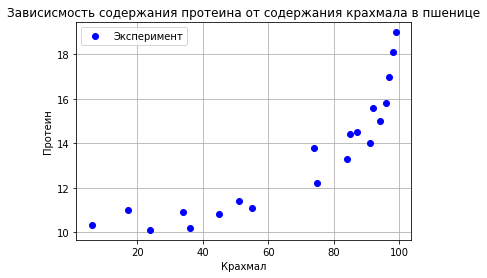

In [2]:
from matplotlib.pyplot import *
from numpy import *
P=array([10.3,12.2,14.5,11.1,10.9,18.1,14.0,10.8,11.4,11,10.2,17,13.8,10.1,14.4,15.8,15.6,15,13.3,19]);
K=array([6,75,87,55,34,98,91,45,51,17,36,97,74,24,85,96,92,94,84,99]);
plot(K,P,'bo',label="Эксперимент");
title('Зависисмость содержания протеина от содержания крахмала в пшенице');
xlabel('Крахмал');
ylabel('Протеин');
grid(True);
legend();
show();

При попытке соединить точки (plot(K,P,'b-o',label="Эксперимент")) график ломается

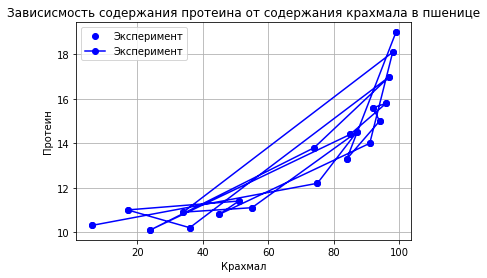

In [3]:
from matplotlib.pyplot import *
from numpy import *
P=array([10.3,12.2,14.5,11.1,10.9,18.1,14.0,10.8,11.4,11,10.2,17,13.8,10.1,14.4,15.8,15.6,15,13.3,19]);
K=array([6,75,87,55,34,98,91,45,51,17,36,97,74,24,85,96,92,94,84,99]);
plot(K,P,'bo',label="Эксперимент");
plot(K,P,'b-o',label="Эксперимент")
title('Зависисмость содержания протеина от содержания крахмала в пшенице');
xlabel('Крахмал');
ylabel('Протеин');
grid(True);
legend();
show();

Это связано с тем, что массивы P и K не упорядочены по возрастанию значений K. Это может мешать и в других моментах решения задачи, поэтому необходимо упорядочить массивы P и K по возрастанию элементов массива K. В Python есть функции сортировки, но так как нужна сортировка двух массивов по возрастанию элементов одного из них, напишем это самостоятельно, воспользовавшись алгоритмом «пузырька».
Код всей программы решения задачи и результаты её работы приведены ниже.

a=
[ 1.15595058e+01 -8.79414289e-02  1.44238327e-03]
b=
[ 9.72146263e+00  8.99538482e-02 -2.57915777e-03  2.49439830e-05]
101
Суммарная квадратичная ошибка для полинома 2-й степени= 14.091120986495465
Суммарная квадратичная ошибка для полинома 3-й степени= 10.353814397308089


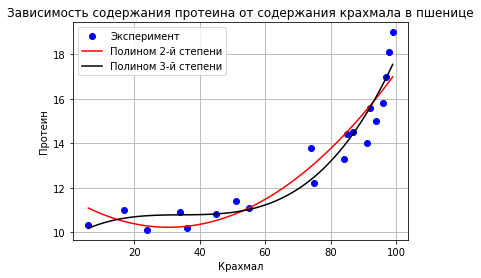

In [4]:
from matplotlib.pyplot import *
from numpy import *
import sys
def printf(format, *args):
    sys.stdout.write(format % args)
P=array([10.3,12.2,14.5,11.1,10.9,18.1,14.0,10.8,11.4,11,10.2,17,13.8,10.1,14.4,15.8,15.6,15,13.3,19]);
K=array([6,75,87,55,34,98,91,45,51,17,36,97,74,24,85,96,92,94,84,99]);
n=K.size;
Mk=sum(K)/n;Mp=sum(P)/n;
for j in range(n-1):
    for i in range (n-1-j):
        if (K[i]>K[i+1]):
            temp=K[i];
            K[i]=K[i+1];
            K[i+1]=temp;
            temp=P[i];
            P[i]=P[i+1];
            P[i+1]=temp;
k=2;
C=ones([k+1,k+1]);
d=ones(k+1);
for i in range(k+1):
    for j in range(k+1):
        C[i][j]=sum(K**(i+j));
    d[i]=sum(P*K**i);
a=linalg.solve(C,d)
k=3;
C=ones([k+1,k+1]);
d=ones(k+1);
for i in range(k+1):
    for j in range(k+1):
        C[i][j]=sum(K**(i+j));
    d[i]=sum(P*K**i);
b=linalg.solve(C,d);
print('a=');
print(a);
print('b=');
print(b);
t=linspace(K[0],K[n-1],101);
N1=t.size;
print(N1);
P2=ones(N1);
P3=ones(N1);
S2=sum((P-a[0]-a[1]*K-a[2]*K**2)**2);
S3=sum((P-b[0]-b[1]*K-b[2]*K**2-b[3]*K**3)**2);
print('Суммарная квадратичная ошибка для полинома 2-й степени=',S2);
print('Суммарная квадратичная ошибка для полинома 3-й степени=',S3);
for i in range(N1):
    P2[i]=a[0]+a[1]*t[i]+a[2]*t[i]**2;
    P3[i]=b[0]+b[1]*t[i]+b[2]*t[i]**2+b[3]*t[i]**3;
plot(K,P,'bo',label="Эксперимент");
plot(t,P2,'r',label="Полином 2-й степени");
plot(t,P3,'k',label="Полином 3-й степени");
title('Зависимость содержания протеина от содержания крахмала в пшенице');
xlabel('Крахмал');
ylabel('Протеин');
grid(True);
legend();
show();

**Задача 7.** В результате опыта холостого хода определена зависимость потребляемой из сети мощности (P , Вт) от входного напряжения (U , В) для асинхронного двигателя (см. табл. 10.4). Методом наименьших квадратов подобрать полином третьей степени.

| <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | <!-- --> | 
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| U,B |132| 140|150| 162 |170| 180 |190 | 200 |211|220 | 232|240| 251 |
| P, кВт | 330|350| 385| 425|450| 485| 540| 600|660|730 |920|1020| 1350|


b=
[-5.15766761e+03  9.55946953e+01 -5.56953276e-01  1.11114559e-03]
Суммарная квадратичная ошибка= 5287.901017538336


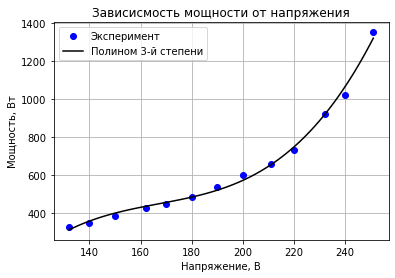

In [5]:
from matplotlib.pyplot import *
from numpy import *
P=array([330, 350, 385, 425, 450, 485, 540, 600, 660, 730, 920, 1020, 1350]);
U=array([132, 140, 150, 162, 170, 180, 190, 200, 211, 220, 232, 240, 251]);
n=U.size;
k=3;
C=ones([k+1,k+1]);
d=ones(k+1);
for i in range(k+1):
    for j in range(k+1):
        C[i][j]=sum(U**(i+j));
    d[i]=sum(P*U**i);
b=linalg.solve(C,d);
print('b=');
print(b);
t=linspace(U[0],U[n-1],101);
N1=t.size;
P3=ones(N1);
S3=sum((P-b[0]-b[1]*U-b[2]*U**2-b[3]*U**3)**2);
print('Суммарная квадратичная ошибка=',S3);
for i in range(N1):
    P3[i]=b[0]+b[1]*t[i]+b[2]*t[i]**2+b[3]*t[i]**3;
plot(U,P,'bo',label="Эксперимент");
plot(t,P3,'k',label="Полином 3-й степени");
title('Зависисмость мощности от напряжения');
xlabel('Напряжение, В');
ylabel('Мощность, Вт');
grid(True);
legend();
show();